# 개념 정리

### 2.4. 파이토치 코드 맛보기

- 범주형 데이터 변환: 범주형 데이터 -> category -> NumPy array -> Tensor
- np.concatenate: 선택한 축을 기준으로 두 개의 배열 연결
- np.stack: 배열들을 새로운 축으로 합침. 두 배열의 차원이 동일해야 함.
- pd.get_dummies: dummy variable로 만들어주는 함수
- 2차원 텐서를 1차원으로 변경: ravel(), reshape(-1), flatten() 사용
- 워드 임베딩: 유사한 단어끼리 유사하게 인코딩되도록 표현하는 방법. 배열을 N차원으로 변경하며, 인베딩 크기는 (칼럼 고유값 수)/2 를 많이 사용함.

모델 네트워크
- class 형태로 구현해 nn.Module 상속
- \_\_init__()으로 파라미터와 신경망을 초기화
- super().\_\_init__()으로 부모 클래스(nn.Module)에 접근
- Linear: 선형 계층. y=Wx+b 수식을 사용한 선형 변환 진행.
- ReLU: 활성화 함수로 사용
- BatchNorm1d: 배치 정규화 용도로 사용
- Dropout: 과적합 방지에 사용
- forward() 함수가 학습 데이터를 입력받아 연산을 진행함.

- 모델 훈련 전 손실 함수와 옵티마이저 정의 필요.
- for문으로 epoch마다 손실 함수가 오차를 계산하고 도합 오차에 누적
- 손실함수의 backward() 메서드 호출로 가중치 업데이트
- 옵티마이저 함수의 step() 메서드로 기울기 업데이트

성능 평가 지표
- 정확도: 전체에서 정답을 맞힌 비율
- 재현율: 정답이 1일 때 1로 예측한 비율
- 정밀도: 1로 예측한 것 중 정답이 1인 비율
- F1-스코어: 정밀도와 재현율의 조화 평균. 2*((정확도*재현율)/(정확도+재현율))

# 코드 필사

### 2.4. 파이토치 코드 맛보기

In [1]:
# 필요한 라이브러리 호출
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# 데이터 호출
cols = ['price', 'maint', 'doors', 'persons', 'lug_capacity', 'safety', 'output']
dataset = pd.read_csv('./data/car.data', names=cols)
display(dataset.head())

,price,maint,doors,persons,lug_capacity,safety,output
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


<Axes: >

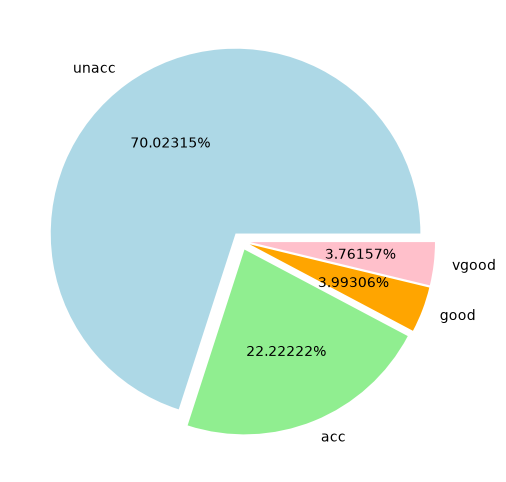

In [3]:
# 예제 데이터셋 분포
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 8
fig_size[1] = 6
plt.rcParams["figure.figsize"] = fig_size
dataset.output.value_counts().plot(kind='pie', autopct='%0.05f%%', 
                                   colors=['lightblue', 'lightgreen', 'orange', 'pink'],
                                   explode=(0.05, 0.05, 0.05, 0.05))

In [4]:
# 데이터를 범주형 타입으로 변환
categorical_columns = ['price', 'maint', 'doors', 'persons', 'lug_capacity', 'safety']

for category in categorical_columns:
    dataset[category] = dataset[category].astype('category')

price = dataset['price'].cat.codes.values
maint = dataset['maint'].cat.codes.values
doors = dataset['doors'].cat.codes.values
persons = dataset['persons'].cat.codes.values
lug_capacity = dataset['lug_capacity'].cat.codes.values
safety = dataset['safety'].cat.codes.values

categorical_data = np.stack([price, maint, doors, persons, lug_capacity, safety], 1)
categorical_data[:10]

array([[3, 3, 0, 0, 2, 1],
       [3, 3, 0, 0, 2, 2],
       [3, 3, 0, 0, 2, 0],
       [3, 3, 0, 0, 1, 1],
       [3, 3, 0, 0, 1, 2],
       [3, 3, 0, 0, 1, 0],
       [3, 3, 0, 0, 0, 1],
       [3, 3, 0, 0, 0, 2],
       [3, 3, 0, 0, 0, 0],
       [3, 3, 0, 1, 2, 1]], dtype=int8)

In [5]:
# 배열을 텐서로 변환
categorical_data = torch.tensor(categorical_data, dtype=torch.int64)
categorical_data[:10]

tensor([[3, 3, 0, 0, 2, 1],
        [3, 3, 0, 0, 2, 2],
        [3, 3, 0, 0, 2, 0],
        [3, 3, 0, 0, 1, 1],
        [3, 3, 0, 0, 1, 2],
        [3, 3, 0, 0, 1, 0],
        [3, 3, 0, 0, 0, 1],
        [3, 3, 0, 0, 0, 2],
        [3, 3, 0, 0, 0, 0],
        [3, 3, 0, 1, 2, 1]])

In [6]:
# 레이블로 사용할 칼럼을 텐서로 변환
outputs = pd.get_dummies(dataset.output)
outputs = outputs.values
outputs = torch.tensor(outputs).flatten()

print(categorical_data.shape)
print(outputs.shape)

torch.Size([1728, 6])
torch.Size([6912])


In [7]:
# 범주형 칼럼을 N차원으로 변환
categorical_column_sizes = [len(dataset[column].cat.categories) for column in categorical_columns]
categorical_embedding_sizes = [(col_size, min(50, (col_size+1)//2)) for col_size in categorical_column_sizes]
print(categorical_embedding_sizes)

[(4, 2), (4, 2), (4, 2), (3, 2), (3, 2), (3, 2)]


In [8]:
# 데이터셋 분리
total_records = 1728
test_records = int(total_records*.2)

categorical_train_data = categorical_data[:total_records - test_records]
categorical_test_data = categorical_data[total_records - test_records:total_records]
train_outputs = outputs[:total_records - test_records]
test_outputs = outputs[total_records - test_records:total_records]

In [9]:
# 데이터셋 분리 확인
print(len(categorical_train_data))
print(len(train_outputs))
print(len(categorical_test_data))
print(len(test_outputs))

1383
1383
345
345


In [10]:
# 모델의 네트워크 생성
class Model(nn.Module):
    def __init__(self, embedding_size, output_size, layers, p=0.4):
        super().__init__()
        self.all_embeddings = nn.ModuleList([nn.Embedding(ni, nf) for ni, nf in embedding_size])
        self.embedding_dropout = nn.Dropout(p)

        all_layers = []
        num_categorical_cols = sum((nf for ni, nf in embedding_size))
        input_size = num_categorical_cols # 입력층의 크기를 찾기 위해 범주형 칼럼 개수를 input_size 변수에 저장

        for i in layers:
            all_layers.append(nn.Linear(input_size, i))
            all_layers.append(nn.ReLU(inplace=True))
            all_layers.append(nn.BatchNorm1d(i))
            all_layers.append(nn.Dropout(p))
            input_size = i

        all_layers.append(nn.Linear(layers[-1], output_size))
        self.layers = nn.Sequential(*all_layers) # 모든 계층에 대한 목록을 클래스로 전달

    def forward(self, x_categorical):
        embeddings = []
        for i, e in enumerate(self.all_embeddings):
            embeddings.append(e(x_categorical[:, i]))
            
        x = torch.cat(embeddings, 1)
        x = self.embedding_dropout(x)
        x = self.layers(x)
        return x

In [11]:
# Model 클래스의 객체 생성
model = Model(categorical_embedding_sizes, 4, [200, 100, 50], p=0.4)
print(model)

Model(
  (all_embeddings): ModuleList(
    (0-2): 3 x Embedding(4, 2)
    (3-5): 3 x Embedding(3, 2)
  )
  (embedding_dropout): Dropout(p=0.4, inplace=False)
  (layers): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=200, out_features=100, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=100, out_features=50, bias=True)
    (9): ReLU(inplace=True)
    (10): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=50, out_features=4, bias=True)
  )
)


In [12]:
# 모델의 파라미터 정의
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [13]:
# CPU/GPU 사용 지정
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

In [14]:
# 모델 학습
epochs = 500
aggregated_losses = []
train_outputs = train_outputs.to(device=device, dtype=torch.int64)

for i in range(epochs):
    i += 1
    y_pred = model(categorical_train_data).to(device)
    single_loss = loss_function(y_pred, train_outputs)
    aggregated_losses.append(single_loss)

    if i%25 == 1:
        print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')

    optimizer.zero_grad()
    single_loss.backward()
    optimizer.step()

print(f'epoch: {i:3} loss: {single_loss.item():10.10f}')

epoch:   1 loss: 1.57919633
epoch:  26 loss: 1.40669358
epoch:  51 loss: 1.30068040
epoch:  76 loss: 1.19687963
epoch: 101 loss: 1.06461990
epoch: 126 loss: 0.94173652
epoch: 151 loss: 0.85082269
epoch: 176 loss: 0.76527900
epoch: 201 loss: 0.71415538
epoch: 226 loss: 0.66342282
epoch: 251 loss: 0.63851511
epoch: 276 loss: 0.62767637
epoch: 301 loss: 0.60878199
epoch: 326 loss: 0.60084677
epoch: 351 loss: 0.59564185
epoch: 376 loss: 0.58258575
epoch: 401 loss: 0.58062059
epoch: 426 loss: 0.57915914
epoch: 451 loss: 0.57876772
epoch: 476 loss: 0.57606423
epoch: 500 loss: 0.5747568011


In [16]:
# 테스트 데이터셋으로 모델 예측
test_outputs = test_outputs.to(dtype=torch.int64)
with torch.no_grad():
    y_val = model(categorical_test_data)
    loss = loss_function(y_val, test_outputs)
print(f'Loss: {loss:.8f}')

Loss: 0.55837673


In [17]:
# 모델의 예측 확인
print(y_val[:5])

tensor([[ 3.1710,  1.6977, -3.7770, -4.0980],
        [ 2.1993,  0.9971, -3.1861, -3.2630],
        [ 2.4352,  1.3082, -3.0419, -3.1463],
        [ 2.3211,  1.6013, -3.2467, -2.9923],
        [ 3.2559,  1.9531, -4.5618, -4.0281]])


In [18]:
# 가장 큰 값을 갖는 인덱스 확인
y_val = np.argmax(y_val, axis=1)
print(y_val[:5])

tensor([0, 0, 0, 0, 0])


In [19]:
# 테스트 데이터셋을 이용한 정확도 확인
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(confusion_matrix(test_outputs, y_val))
print(classification_report(test_outputs, y_val))
print(accuracy_score(test_outputs, y_val))

[[258   0   1]
 [ 85   1   0]
 [  0   0   0]]
              precision    recall  f1-score   support

           0       0.75      1.00      0.86       259
           1       1.00      0.01      0.02        86
           2       0.00      0.00      0.00         0

    accuracy                           0.75       345
   macro avg       0.58      0.34      0.29       345
weighted avg       0.81      0.75      0.65       345

0.7507246376811594


f:\ESAA\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\ESAA\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\ESAA\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
